In [82]:
import math
import json
import time
import calendar
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Define Dataset

In [83]:
df = pd.read_csv('riverlevel.csv')  # import dataset

# convert month name to integer
month_dict = dict((v, k) for k, v in enumerate(calendar.month_name))
df['Month'] = df['Month'].map(month_dict)

# create datetime column
df[['Year', 'Month', 'Day', 'Hour']] = df[['Year', 'Month', 'Day', 'Hour']].astype(int)
df['Hour'] = df['Hour'].apply(lambda x: x if x < 24 else 0)

# convert year, month, day, and hour columns into timestamp
df['Datetime'] = df[['Year', 'Month', 'Day', 'Hour']].apply(lambda row: datetime(row['Year'], row['Month'], row['Day'], row['Hour']).isoformat(), axis=1)
df["Datetime"] = pd.to_datetime(df["Datetime"], format='ISO8601')

# assign timestamps as the data frame index
df.index = df["Datetime"]
df = df.drop(['Datetime'], axis=1)

# select the parameters
df = df[['Waterlevel', 'Waterlevel.1', 'Waterlevel.2', 'Waterlevel.3', 'RF-Intensity', 'RF-Intensity.2', 'RF-Intensity.3', 'Precipitation', 'Precipitation.1', 'Precipitation.2', 'Humidity', 'Humidity.1', 'Humidity.2', 'Temperature', 'Temperature.1', 'Temperature.2']] 
df = df.astype(np.float64)  # convert parameters into a double precision floating number

# fill in missing values using linear interpolation
df = df.interpolate(method='linear', limit_direction='forward')
df = df.resample('6H').max()  # resample dataset using the max value for each 24-hours
df = df.rolling(120).mean().dropna()  # perform moving average smoothing

df.head(10)  # display data frame

,Waterlevel,Waterlevel.1,Waterlevel.2,Waterlevel.3,RF-Intensity,RF-Intensity.2,RF-Intensity.3,Precipitation,Precipitation.1,Precipitation.2,Humidity,Humidity.1,Humidity.2,Temperature,Temperature.1,Temperature.2
Datetime,,,,,,,,,,,,,,,,
2012-01-30 18:00:00,15.846000,12.326500,12.326500,21.908917,0.408333,0.241667,0.241667,0.387917,0.387917,0.387917,17.221333,17.221333,17.221333,25.270667,25.270667,25.270667
2012-01-31 00:00:00,15.845667,12.322500,12.322500,21.907500,0.408333,0.241667,0.241667,0.391917,0.391917,0.391917,17.214667,17.214667,17.214667,25.255583,25.255583,25.255583
2012-01-31 06:00:00,15.845250,12.318500,12.318500,21.905917,0.408333,0.241667,0.241667,0.399583,0.399583,0.399583,17.214083,17.214083,17.214083,25.258750,25.258750,25.258750
2012-01-31 12:00:00,15.844833,12.314500,12.314500,21.904408,0.408333,0.250000,0.250000,0.406500,0.406500,0.406500,17.217167,17.217167,17.217167,25.261667,25.261667,25.261667
2012-01-31 18:00:00,15.843833,12.310500,12.310500,21.902883,0.408333,0.250000,0.250000,0.409917,0.409917,0.409917,17.219667,17.219667,17.219667,25.263500,25.263500,25.263500
2012-02-01 00:00:00,15.843500,12.306500,12.306500,21.901339,0.408333,0.250000,0.250000,0.418417,0.418417,0.418417,17.221667,17.221667,17.221667,25.266083,25.266083,25.266083
2012-02-01 06:00:00,15.843167,12.302500,12.302500,21.899864,0.408333,0.250000,0.250000,0.427417,0.427417,0.427417,17.218167,17.218167,17.218167,25.244167,25.244167,25.244167
2012-02-01 12:00:00,15.842750,12.298500,12.298500,21.898372,0.408333,0.216667,0.216667,0.435417,0.435417,0.435417,17.214083,17.214083,17.214083,25.223667,25.223667,25.223667
2012-02-01 18:00:00,15.842417,12.294500,12.294500,21.896947,0.408333,0.216667,0.216667,0.435250,0.435250,0.435250,17.210000,17.210000,17.210000,25.220083,25.220083,25.220083


### Normalize Dataset using MinMax Normalization

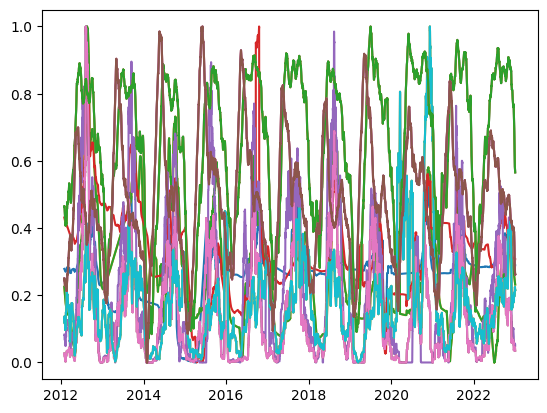

In [84]:
dataset_min = df.min()
dataset_max = df.max()

normalized_df = (df - dataset_min) / (dataset_max - dataset_min)

plt.plot(normalized_df)
plt.show()

### Define Model

In [85]:
BATCH_SIZE = 128
SEQ_LEN = 60
SEQ_STEP = 60
PRED_SIZE = 4
D_MODEL = 16
NUM_HEADS = 4
D_FF = 2048 

In [86]:
# neural network functions
def linear_activation(input, weights, biases):
    batch_size, seq_length, d_model = input.shape  # extract input shape
    
    x_flat = np.reshape(input, (batch_size * seq_length, d_model))  # flatten input into (batch_size, d_model)
    z_flat = np.dot(x_flat, weights.T) + biases
    
    return np.reshape(z_flat, (batch_size, seq_length, -1))  # reshape back to (batch_size, seq_length, d_model)


def relu(input):
    batch_size, seq_length, d_model = input.shape  # extract input shape
    
    x_flat = np.reshape(input, (batch_size * seq_length, d_model))  # flatten input into (batch_size, d_model)
    a_flat = np.maximum(x_flat, 0) 
    
    return np.reshape(a_flat, (batch_size, seq_length, -1))  # reshape back to (batch_size, seq_length, d_model)


def sigmoid(input):
    batch_size, seq_length, d_model = input.shape  # extract input shape
    
    x_flat = np.reshape(input, (batch_size * seq_length, d_model))  # flatten input into (batch_size, d_model)
    a_flat = 1 / (1 + np.exp(-x_flat))
    
    return np.reshape(a_flat, (batch_size, seq_length, -1))  # reshape back to (batch_size, seq_length, d_model)


def softmax(input):
    batch_size, seq_length, d_model = input.shape
    
    x_flat = np.reshape(input, (batch_size * seq_length, d_model)).T  # flatten input into (batch_size, d_model)
    a_flat = np.exp(x_flat) / (np.sum(np.exp(x_flat), axis=0) + 1e-8)
    
    return np.reshape(a_flat.T, (batch_size, seq_length, -1))  # reshape back to (batch_size, seq_length, d_model)


def layer_normalization(input, gamma, beta):
    mean = np.mean(input, axis=-1, keepdims=True)  # get mean in each axis
    std = np.std(input, axis=-1, keepdims=True)  # get standard deviation in each axis
    
    normalized = (input - mean) / (std + 1e-8)  # normalized activations 
    
    # reshape parameters to fit the input shape
    gamma = np.reshape(gamma, (1, 1, -1))
    beta = np.reshape(beta, (1, 1, -1))
    
    return gamma * normalized + beta  # normalized activations with size of (batch_size, seq_length, d_model)

#### Positional Encoding

Unlike human brains, neural networks are not aware of order. It cannot distinguish past values from future values. That is why, the purpose of positional encoding is to help the model distinguish between different elements in a sequence and understand the sequential order of data.

In [87]:
# positional encoding
def positional_encoding(input, n=10000):
    batch_size, seq_length, d_model = input.shape
    
    pe = np.zeros(shape=(seq_length, d_model))
    for k in range(seq_length):
        for i in np.arange(int(d_model / 2)):
            denominator = np.power(n, 2 * i / d_model)
            pe[k, 2*i] = np.sin(k / denominator)
            pe[k, 2*i+1] = np.cos(k / denominator)
            
    return input + pe  # add positional encoding to input

#### Attention Mechanism

In the context of forecasting, a multi-head attention mechanism allows the model to weigh the importance of different time points in a time period thus allowing the model to capture the relationship between past events and current events. The attention scores are calculated by comparing the input sequence (after linear projection) against itself or against a query vector. In addition, the diagonal mask ensure that the attention mechanism only compares past events to future events but not vice versa to avoid over fitting.

In [88]:
# multi-head attention
def split_heads(input, num_heads):
    batch_size, seq_length, d_model = input.shape
    
    assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
    head_dim = d_model // num_heads
    
    heads = np.reshape(input, (batch_size, seq_length, num_heads, head_dim))
    heads = np.transpose(heads, (0, 2, 1, 3))
    
    return heads  # attention heads with size of (batch_size, num_heads, seq_length, head_dim)


def combine_heads(input):
    combined = np.transpose(input, (0, 2, 1, 3))
    combined = np.reshape(combined, (combined.shape[0], combined.shape[1], -1))
    
    return combined  # combined attention heads with size of (batch_size, seq_length, d_model)


def scaled_dot_product_attention(query, key, value):
    batch_size, num_heads, seq_length, head_dim = query.shape
    
    # convert input into (batch_size, seq_length, d_model)
    query = np.reshape(query, (batch_size * num_heads, seq_length, head_dim))  
    key = np.reshape(key, (batch_size * num_heads, seq_length, head_dim))
    value = np.reshape(value, (batch_size * num_heads, seq_length, head_dim))
    
    key = np.transpose(key, (0, 2, 1))  # transpose key
    attn_scores = np.matmul(query, key) / math.sqrt(head_dim)  # get dot product attention
    
    attn_scores = softmax(attn_scores)  # convert attention scores into probabilities
    
    value = np.matmul(attn_scores, value)  # embed attention scores into value
    
    return np.reshape(attn_scores, (batch_size, num_heads, seq_length, seq_length)), np.reshape(value, (batch_size, num_heads, seq_length, head_dim))  # reshape to original size


def multi_head_self_attention(query, key, value, num_heads, params):
    query = split_heads(linear_activation(query, params[0], params[1]), num_heads)
    key = split_heads(linear_activation(key, params[2], params[3]), num_heads)
    value = split_heads(linear_activation(value, params[4], params[5]), num_heads)
    
    attn_scores, attn_output = scaled_dot_product_attention(query, key, value)
    attn_output = linear_activation(combine_heads(attn_output), params[6], params[7])
    
    return attn_scores, attn_output

#### Feed Forward Network

Feed Forward Network is a fundamental type of artificial neural network. In the context of transformer models, the feed forward network aims to learn the relationship between the temporal features and the forecasted values.

In [89]:
# feed forward network
def feed_forward_network(input, params):
    out = linear_activation(input, params[0], params[1])
    out = relu(out)
    out = linear_activation(out, params[2], params[3])
    
    return out

#### Encoder Layer

The Encoder layer is the combination of global attention mechanisms and a feed forward network. The primary purpose of the encoder layer is to transform input sequences into a higher-dimensional representation that captures important features and relationships within the time-series data.

In [90]:
# decoder layer
def transformer_encoder(input, num_heads, params):
    attn_scores, attn_out = multi_head_self_attention(
        query=input,
        key=input, 
        value=input, 
        num_heads=num_heads, 
        params=params[:8])
    norm1 = layer_normalization(input + attn_out, params[12], params[13])
    ff_out = feed_forward_network(norm1, params[8:12])
    norm2 = layer_normalization(norm1 + ff_out, params[14], params[15])
    
    return attn_scores, norm2

In [91]:
# model
def transformer(input, num_heads, params):
    out = positional_encoding(input)
    
    # decoder layers
    _, out = transformer_encoder(out, num_heads, params[:16])
    scores, out = transformer_encoder(out, num_heads, params[16:32])
    
    # final layer
    out = linear_activation(out, params[32], params[33])
    out = sigmoid(out)
    
    return scores, out

#### Load Model Parameters

In [92]:
# load parameters from file
with open("parameters.json", "r") as parameters:
    saved_params = json.load(parameters)
    
# iterate through layer parameters
params = []
for key in saved_params.keys():
    param = np.asarray(saved_params[key], dtype=np.float32)  # convert saved parameters back to numpy
    params.append(param)
    
len(params)  # print number of layer parameters

34

### Prepare Test Data

In [93]:
test_data = normalized_df['2021-01-01':].values
dataset_len = len(test_data) - (SEQ_LEN + SEQ_STEP) + 1

# prepare batches
batches = []
for index in range(dataset_len):
    in_start = index
    in_end = in_start + SEQ_LEN
    out_start = index + SEQ_STEP
    out_end = out_start + SEQ_LEN
    
    input = test_data[in_start:in_end]
    label = test_data[out_start:out_end, :PRED_SIZE]
    
    batches.append((np.array(input), np.array(label)))
    
print('Number of batches:', len(batches))

Number of batches: 2801


In [94]:
def inverse_transform(data):
    data_min = dataset_min[['Waterlevel', 'Waterlevel.1', 'Waterlevel.2', 'Waterlevel.3']].to_numpy()
    data_max = dataset_max[['Waterlevel', 'Waterlevel.1', 'Waterlevel.2', 'Waterlevel.3']].to_numpy()
    
    return (data_max - data_min) * data + data_min


def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

In [95]:
accuracy = []
predictions = []
for input, label in batches:
    
    input = np.reshape(input, (1, SEQ_LEN, D_MODEL))
    scores, pred = transformer(input=input, num_heads=NUM_HEADS, params=params)  # make forecast
    pred = np.reshape(pred, (SEQ_LEN, PRED_SIZE))  
    pred = inverse_transform(pred[:, :4])  # scale output to original value
    pred = pred[-SEQ_STEP:]   # get only the forecast window
    
    ground = inverse_transform(label[:, :4])  # scale output to original value
    ground = ground[-SEQ_STEP:]  # get only the forecast window
    
    accuracy.append(mean_absolute_error(ground, pred))  # collect mean absolute error of each window
    predictions.append(np.concatenate((pred[0], ground[0])))  # collect first element of output

# consolidate results
accuracy_df = pd.DataFrame(np.array(accuracy), columns=['MAE'])
predictions_df = pd.DataFrame(np.array(predictions), columns=['P_Waterlevel', 'P_Waterlevel.1', 'P_Waterlevel.2', 'P_Waterlevel.3', 'T_Waterlevel', 'T_Waterlevel.1', 'T_Waterlevel.2', 'T_Waterlevel.3'])
metric_df = pd.concat([accuracy_df, predictions_df], axis=1)
metric_df.index = df.index[-len(metric_df):]

metric_df = metric_df.resample('24H').max()

metric_df.to_csv('results.csv')  # save test results

metric_df.head(10)

,MAE,P_Waterlevel,P_Waterlevel.1,P_Waterlevel.2,P_Waterlevel.3,T_Waterlevel,T_Waterlevel.1,T_Waterlevel.2,T_Waterlevel.3
Datetime,,,,,,,,,
2021-01-30,0.497834,15.757661,12.317157,12.313047,21.083308,15.817826,12.746213,12.746213,21.756250
2021-01-31,0.494474,15.759508,12.331649,12.327522,21.095949,15.817510,12.743925,12.743925,21.756250
2021-02-01,0.493425,15.760411,12.338524,12.334294,21.101542,15.816300,12.734825,12.734825,21.756250
2021-02-02,0.495527,15.760921,12.342468,12.338165,21.104723,15.815176,12.724607,12.724607,21.756000
2021-02-03,0.491515,15.762347,12.350615,12.346308,21.111732,15.837998,12.734888,12.734888,21.786667
2021-02-04,0.478397,15.766950,12.367805,12.363597,21.126561,15.886859,12.766407,12.766407,21.838667
2021-02-05,0.440214,15.772538,12.393118,12.389041,21.149004,15.962389,12.806653,12.806653,21.874000
2021-02-06,0.414625,15.776810,12.413098,12.409152,21.166815,16.038004,12.806049,12.806049,21.878417
2021-02-07,0.396753,15.779894,12.427992,12.424110,21.180100,16.113704,12.803488,12.803488,21.882083


In [96]:
print('Average Mean Absolute Error:', metric_df['MAE'].mean())
print('Mean Absolute Error STD:', metric_df['MAE'].std())

Average Mean Absolute Error: 0.24842787900486427
Mean Absolute Error STD: 0.08168831917108572


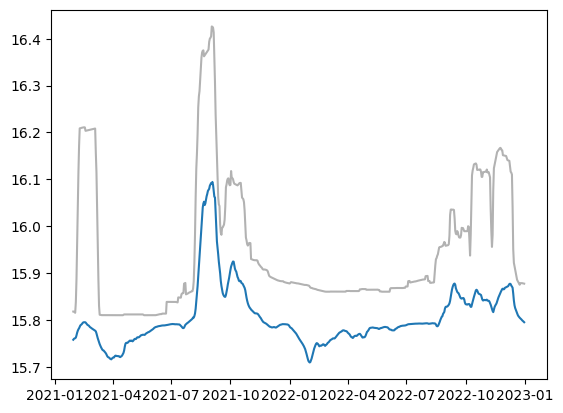

In [97]:
plt.plot(metric_df['P_Waterlevel'])  # plot predictions
plt.plot(metric_df['T_Waterlevel'], color='k', alpha=0.3)  # plot observed value
plt.show()

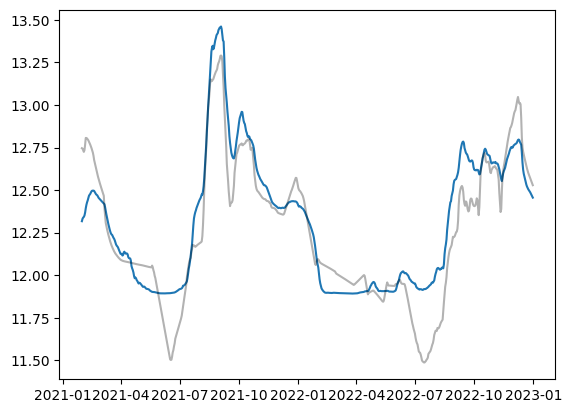

In [98]:
plt.plot(metric_df['P_Waterlevel.1'])  # plot predictions
plt.plot(metric_df['T_Waterlevel.1'], color='k', alpha=0.3)  # plot observed value
plt.show()

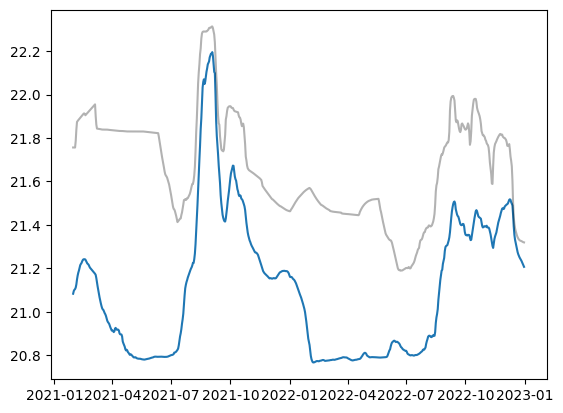

In [99]:
plt.plot(metric_df['P_Waterlevel.3'])  # plot predictions
plt.plot(metric_df['T_Waterlevel.3'], color='k', alpha=0.3)  # plot observed value
plt.show()